# EDA: Median Rent and Distance to Melbourne CBD


## 1) Basic data characteristics

In [38]:
print('Dataset structure')
print(f'final_panel rows: {len(panel):,}')
print(f'final_panel cols: {panel.shape[1]}')
print(f'year range: {panel.year.min()} to {panel.year.max()}')
print(f'n years: {panel.year.nunique()}')
print(f'n LGAs: {panel.lga_name.nunique()}')
print(f'unique LGA-year cells: {panel[["lga_name","year"]].drop_duplicates().shape[0]:,}')

Dataset structure
final_panel rows: 8,334
final_panel cols: 17
year range: 1999 to 2025
n years: 27
n LGAs: 79
unique LGA-year cells: 2,133


In [39]:
print('Rows per LGA-year (structure check)')
dup = panel.groupby(['lga_name','year']).size()
print((dup > 1).sum(), 'of', dup.shape[0], 'cells have >1 row')
print('Distribution:')
print(dup.value_counts().sort_index())

Rows per LGA-year (structure check)
2131 of 2133 cells have >1 row
Distribution:
1       2
2       9
3     174
4    1948
Name: count, dtype: int64


In [40]:
print('Missingness (%) in final_panel (post-reclean)')
missing = (panel.isna().mean() * 100).sort_values(ascending=False)
print(missing.round(2))

print('\nCoverage diagnostics for key variables')
for col in ['offence_count','straight_line_km','independent_schools','gp_clinics_per_1000','dental_sites_per_1000']:
    na_rows = int(panel[col].isna().sum())
    na_lga = int(panel.loc[panel[col].isna(), 'lga_name'].nunique())
    print(f'{col}: missing_rows={na_rows}, missing_lga={na_lga}')

print('\nSource coverage checks')
print(f'crime_clean years: {crime.year.min()} to {crime.year.max()} (n={crime.year.nunique()})')
print(f'distance_clean LGAs: {distance.lga_name.nunique()}')
print(f'schools_clean LGAs: {schools.lga_name.nunique()}')
print(f'health_clean LGAs: {health.lga_name.nunique()}')

Missingness (%) in final_panel (post-reclean)
offence_count             63.21
driving_km                60.57
address                   60.57
straight_line_km          60.57
longitude                 60.57
latitude                  60.57
suburb                    60.57
independent_schools       21.14
dental_sites_per_1000      8.74
gp_clinics_per_1000        1.14
pharmacies_per_1000        0.00
acsc_per_1000              0.00
year                       0.00
allied_health_per_1000     0.00
total_schools              0.00
median_rent                0.00
lga_name                   0.00
dtype: float64

Coverage diagnostics for key variables
offence_count: missing_rows=5268, missing_lga=79
straight_line_km: missing_rows=5048, missing_lga=48
independent_schools: missing_rows=1762, missing_lga=17
gp_clinics_per_1000: missing_rows=95, missing_lga=1
dental_sites_per_1000: missing_rows=728, missing_lga=7

Source coverage checks
crime_clean years: 2016 to 2025 (n=10)
distance_clean LGAs: 31
schoo

In [41]:
num_cols = panel.select_dtypes(include='number').columns
summary = panel[num_cols].describe().T
summary['skew'] = panel[num_cols].skew(numeric_only=True)
summary[['count','mean','std','min','25%','50%','75%','max','skew']]

,count,mean,std,min,25%,50%,75%,max,skew
year,8334.0,2011.995680,7.659264,1999.0000,2005.0000,2012.0000,2019.0000,2025.0000,-0.000294
median_rent,8334.0,280.945044,117.209531,73.0000,185.0000,260.0000,360.0000,743.0000,0.615511
offence_count,3066.0,6762.436399,7073.699837,76.0000,1179.0000,4150.0000,10902.0000,46695.0000,1.638750
independent_schools,6572.0,3.741935,3.187594,0.0000,1.0000,3.0000,5.0000,18.0000,1.984248
total_schools,8334.0,29.191985,20.045618,3.0000,13.0000,23.0000,42.0000,96.0000,1.115921
gp_clinics_per_1000,8239.0,0.421289,0.268940,0.1000,0.3000,0.3000,0.5000,1.8000,2.935004
allied_health_per_1000,8334.0,0.945488,0.355172,0.2000,0.7000,0.9000,1.1000,2.5000,1.086567
dental_sites_per_1000,7606.0,0.272127,0.162059,0.0000,0.2000,0.2000,0.3000,1.1000,2.106629
pharmacies_per_1000,8334.0,0.272918,0.148708,0.1000,0.2000,0.2000,0.3000,0.9000,2.232220
acsc_per_1000,8334.0,28.389621,7.304069,13.3000,24.3000,27.3000,31.7000,56.0000,0.886985


### Visual diagrams
The following charts illustrate variable distributions, and key first-order relationships.

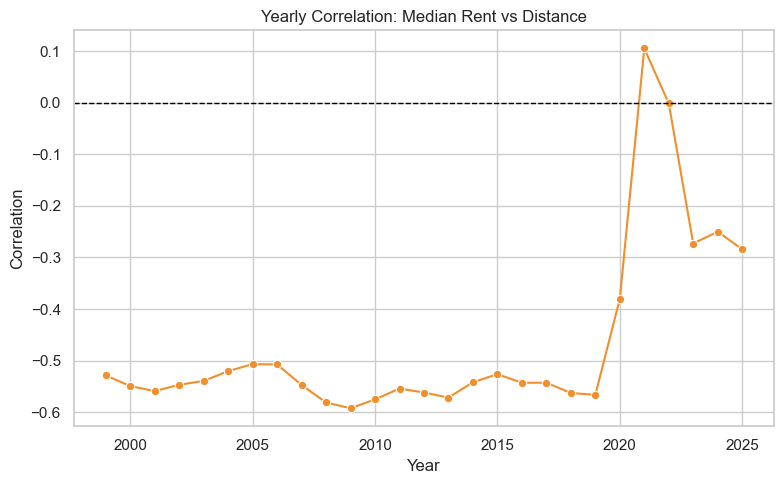

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 5) Yearly correlation trend (rent vs distance)
year_corr_plot = (
    panel.dropna(subset=['median_rent', 'straight_line_km'])
         .groupby('year')
         .apply(lambda g: g['median_rent'].corr(g['straight_line_km']))
         .rename('corr_rent_distance')
)

plt.figure(figsize=(8, 5))
sns.lineplot(x=year_corr_plot.index, y=year_corr_plot.values, marker='o', color='#F28E2B')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Correlation')
plt.title('Yearly Correlation: Median Rent vs Distance')
plt.tight_layout()
plt.show()

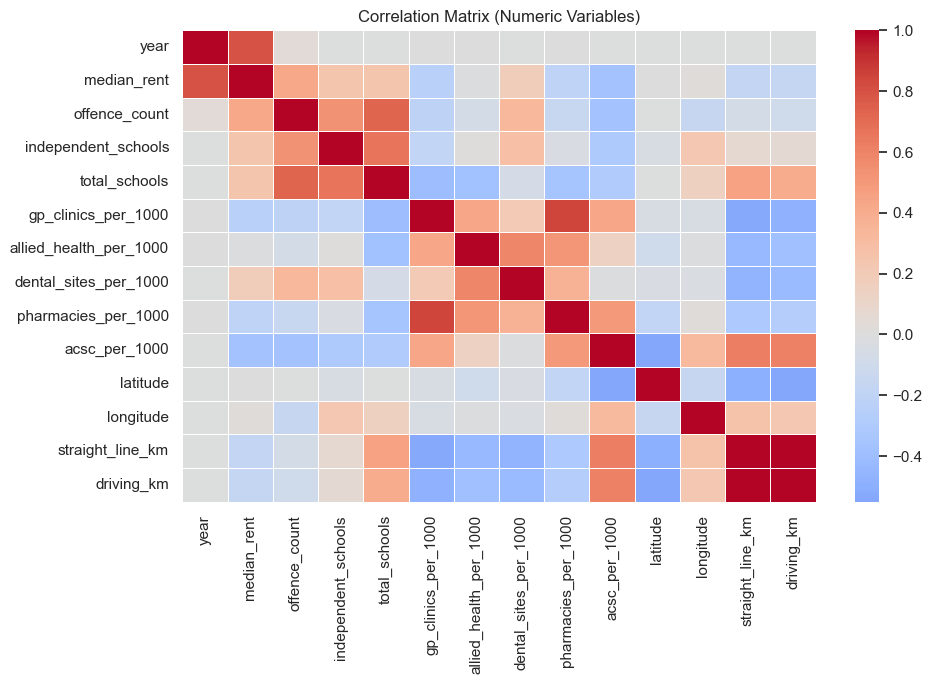

In [43]:
# 4) Correlation heatmap for numeric variables
corr = panel.select_dtypes(include='number').corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Variables)')
plt.tight_layout()
plt.show()

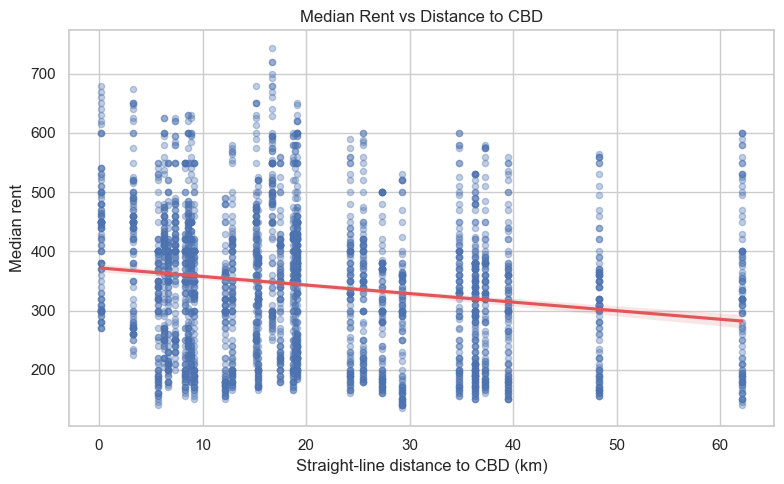

In [44]:
# 3) Rent-distance relationship
plot_df = panel[['median_rent', 'straight_line_km']].dropna()
plt.figure(figsize=(8, 5))
sns.regplot(data=plot_df, x='straight_line_km', y='median_rent',
            scatter_kws={'alpha': 0.35, 's': 20}, line_kws={'color': '#E15759'})
plt.xlabel('Straight-line distance to CBD (km)')
plt.ylabel('Median rent')
plt.title('Median Rent vs Distance to CBD')
plt.tight_layout()
plt.show()

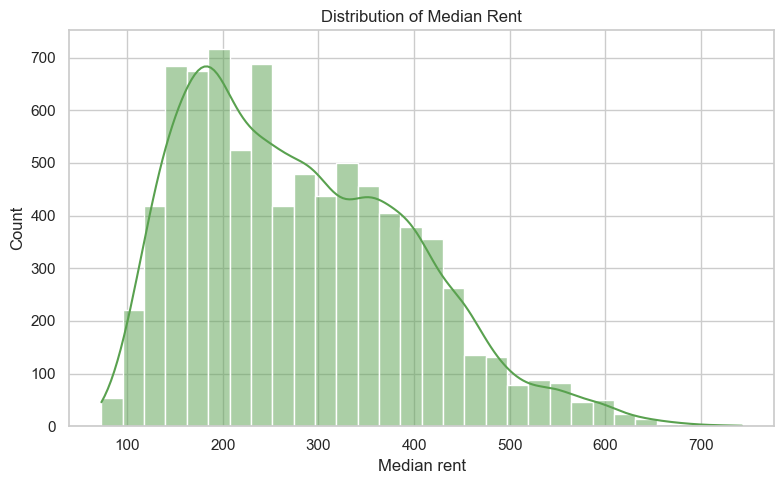

In [45]:
# 2) Distribution of median rent
plt.figure(figsize=(8, 5))
sns.histplot(panel['median_rent'].dropna(), bins=30, kde=True, color='#59A14F')
plt.xlabel('Median rent')
plt.title('Distribution of Median Rent')
plt.tight_layout()
plt.show()

## 2) Exploratory analysis of variable correlation

In [46]:
def safe_corr(x, y):
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    return x[m].corr(y[m])

print('Key first-order correlations')
print('corr(median_rent, straight_line_km):', round(safe_corr(panel['median_rent'], panel['straight_line_km']), 4))
print('corr(median_rent, driving_km):', round(safe_corr(panel['median_rent'], panel['driving_km']), 4))
print('corr(straight_line_km, driving_km):', round(safe_corr(panel['straight_line_km'], panel['driving_km']), 4))
print('corr(median_rent, offence_count):', round(safe_corr(panel['median_rent'], panel['offence_count']), 4))

Key first-order correlations
corr(median_rent, straight_line_km): -0.1769
corr(median_rent, driving_km): -0.1632
corr(straight_line_km, driving_km): 0.9904
corr(median_rent, offence_count): 0.4222


In [47]:
agg = panel.groupby(['lga_name','year'], as_index=False).agg({
    'median_rent': 'mean',
    'straight_line_km': 'mean',
    'driving_km': 'mean',
    'offence_count': 'mean'
})

print('corr after LGA-year aggregation:')
print('corr(median_rent, straight_line_km):', round(safe_corr(agg['median_rent'], agg['straight_line_km']), 4))

lga_means = agg.groupby('lga_name', as_index=False)[['median_rent','straight_line_km']].mean()
print('between-LGA correlation (LGA means):')
print('corr(mean_rent_by_LGA, mean_distance_by_LGA):', round(safe_corr(lga_means['median_rent'], lga_means['straight_line_km']), 4))

corr after LGA-year aggregation:
corr(median_rent, straight_line_km): -0.1731
between-LGA correlation (LGA means):
corr(mean_rent_by_LGA, mean_distance_by_LGA): -0.4926


In [48]:
year_corr = (
    agg.dropna(subset=['median_rent','straight_line_km'])
       .groupby('year')
       .apply(lambda g: g['median_rent'].corr(g['straight_line_km']))
       .rename('corr_rent_distance')
)
print('Year-by-year rent-distance correlation summary')
print(year_corr.describe()[['min','50%','max']])
year_corr.to_frame().head()

Year-by-year rent-distance correlation summary
min   -0.597733
50%   -0.546997
max    0.108017
Name: corr_rent_distance, dtype: float64


,corr_rent_distance
year,
1999,-0.531645
2000,-0.552054
2001,-0.562441
2002,-0.549226
2003,-0.541898


## 3) What data cleaning changed

- LGA normalization removed CITY/SHIRE/COUNCIL text, but unresolved suffixes like (C)/(S)/(RC) still weaken merge quality.
- Rent cleaning preserved multiple observations per LGA-year (quarter information retained after extracting year).
- Distance data covers a metropolitan subset, creating structural missingness for non-covered LGAs.

### What we learned
- Cleaning succeeded for core rent and distance analysis, but key controls are still limited by merge and coverage issues.